In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [4]:
df.shape

(545, 13)

In [5]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

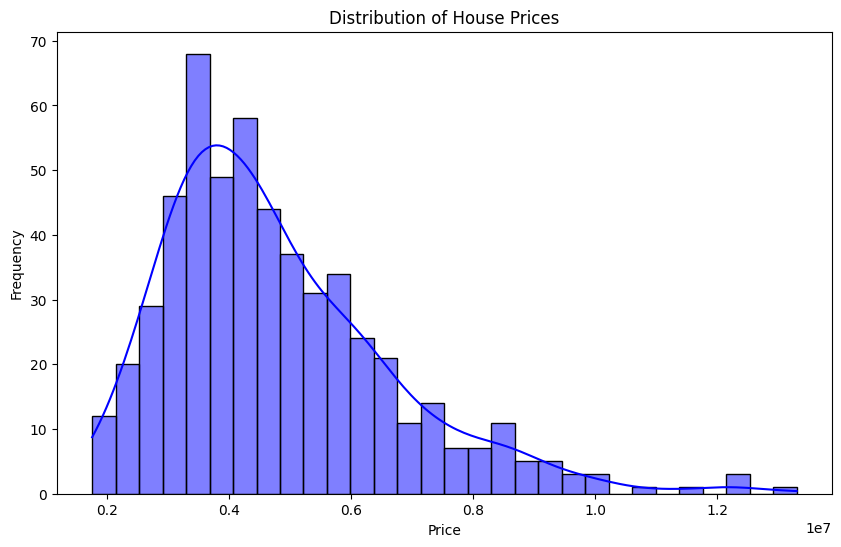

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

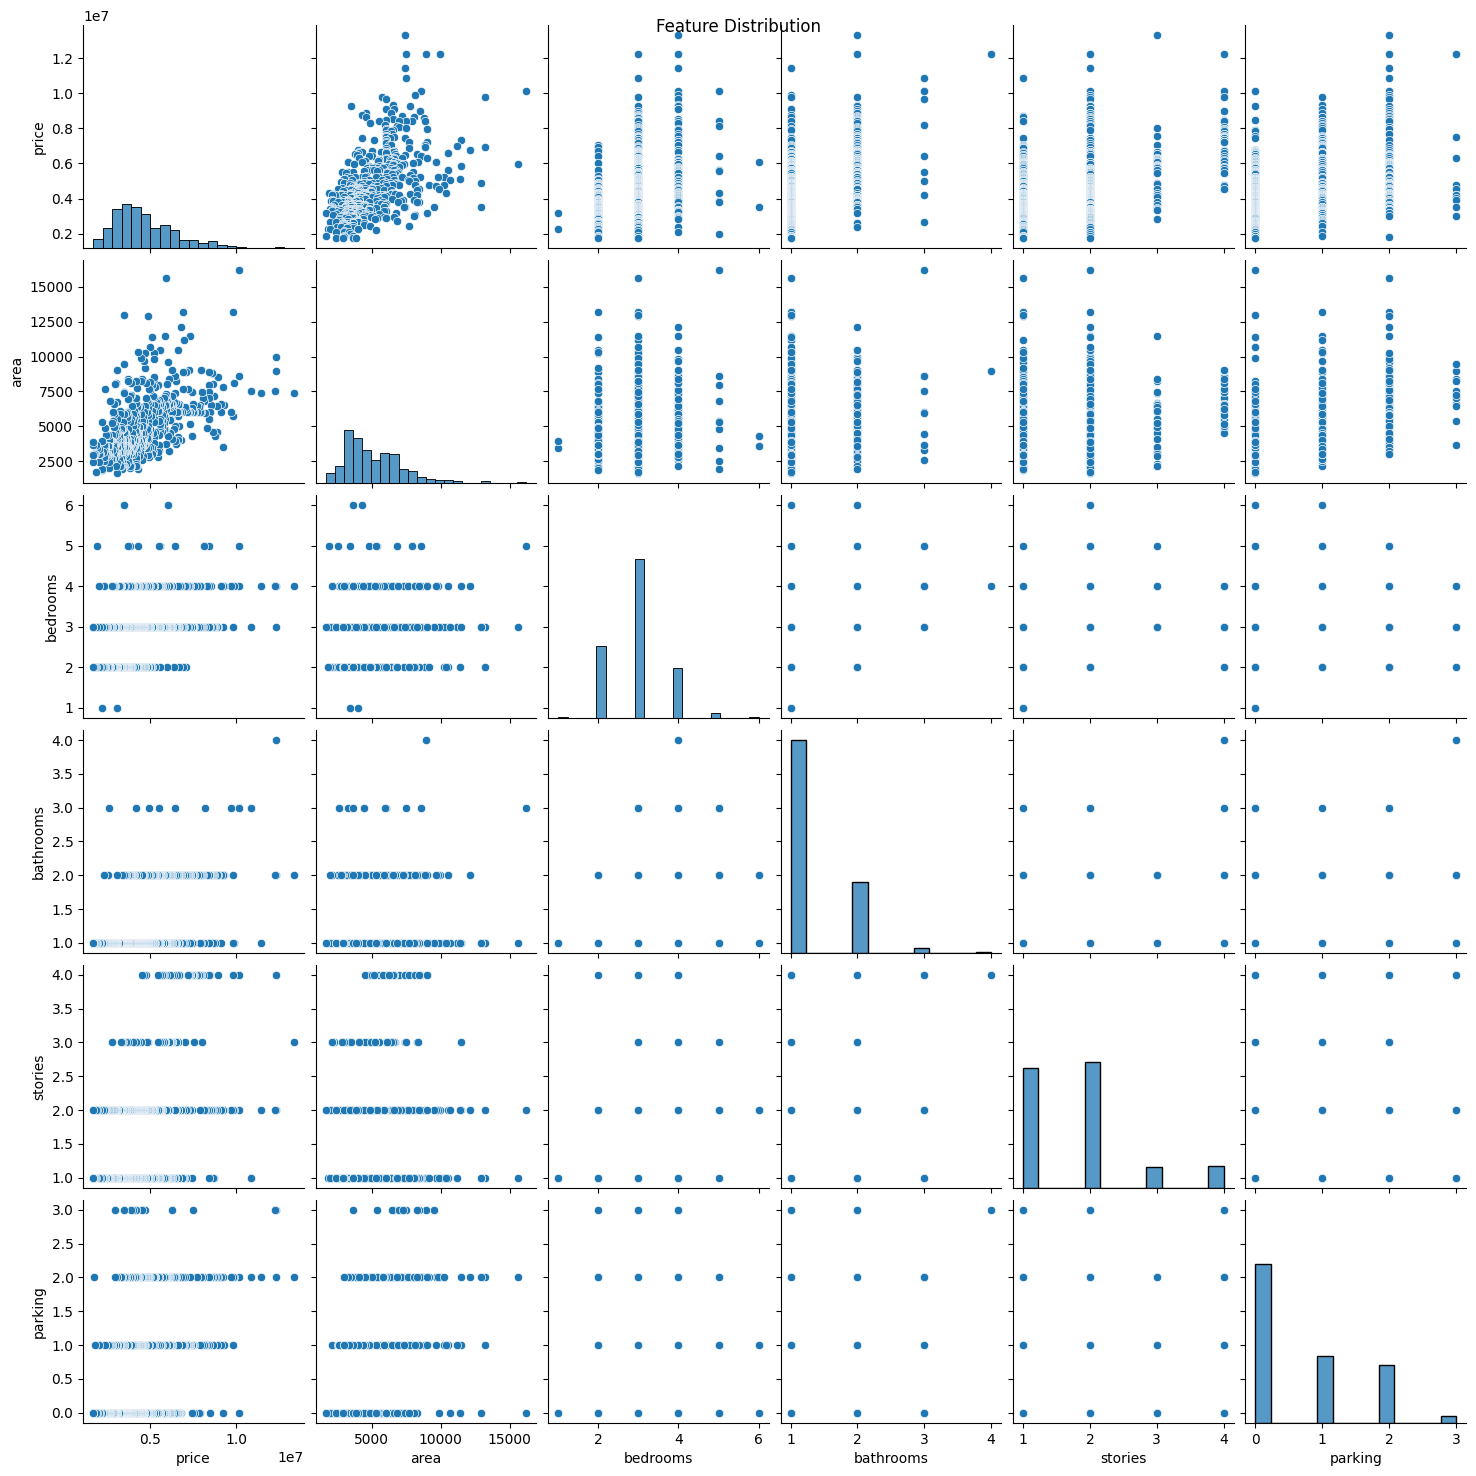

In [7]:
# Feature Distribution
sns.pairplot(df)
plt.suptitle("Feature Distribution")
plt.show()

In [8]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [9]:
# Label Encoding
columns = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea", "furnishingstatus"]
encoder = LabelEncoder()
for column in columns:
  df[column] = encoder.fit_transform(df[column])

In [10]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,int64
guestroom,int64
basement,int64
hotwaterheating,int64
airconditioning,int64


In [11]:
X = df.drop(columns=["price"])
y = df["price"]

In [12]:
X = X.astype(np.float32)
y = y.astype(np.float32)

print(X.dtypes)

area                float32
bedrooms            float32
bathrooms           float32
stories             float32
mainroad            float32
guestroom           float32
basement            float32
hotwaterheating     float32
airconditioning     float32
parking             float32
prefarea            float32
furnishingstatus    float32
dtype: object


In [13]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X)

# Reshape y to be 2-dimensional (1 column)
y_scaled = scaler_y.fit_transform(y.to_frame())


In [14]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

In [15]:
X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train)
X_test_tensor = torch.from_numpy(X_test)
y_test_tensor = torch.from_numpy(y_test)

**Model Training**

In [16]:
class HousePriceModel(nn.Module):
    def __init__(self):
        super(HousePriceModel, self).__init__()
        self.linear1 = nn.Linear(in_features=12, out_features=24)
        self.relu1 = nn.ReLU()
        self.linear2 = nn.Linear(in_features=24, out_features=6)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(in_features=6, out_features=1)

    def forward(self, x):
        x = self.linear1(x)
        x = self.relu1(x)
        x = self.linear2(x)
        x = self.relu2(x)
        x = self.output(x)
        return x

In [17]:
model = HousePriceModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [18]:
epochs = 1000
for epoch in range(epochs):
    model.train()
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1} / {epochs}, Loss: {loss.item():.4f}")

Epoch 50 / 1000, Loss: 0.8215
Epoch 100 / 1000, Loss: 0.7914
Epoch 150 / 1000, Loss: 0.7608
Epoch 200 / 1000, Loss: 0.7290
Epoch 250 / 1000, Loss: 0.6967
Epoch 300 / 1000, Loss: 0.6634
Epoch 350 / 1000, Loss: 0.6267
Epoch 400 / 1000, Loss: 0.5913
Epoch 450 / 1000, Loss: 0.5577
Epoch 500 / 1000, Loss: 0.5266
Epoch 550 / 1000, Loss: 0.4984
Epoch 600 / 1000, Loss: 0.4729
Epoch 650 / 1000, Loss: 0.4493
Epoch 700 / 1000, Loss: 0.4276
Epoch 750 / 1000, Loss: 0.4079
Epoch 800 / 1000, Loss: 0.3901
Epoch 850 / 1000, Loss: 0.3741
Epoch 900 / 1000, Loss: 0.3597
Epoch 950 / 1000, Loss: 0.3470
Epoch 1000 / 1000, Loss: 0.3357


In [19]:
model.eval()
with torch.no_grad():
    test_preds = model(X_test_tensor)
    test_loss = criterion(test_preds, y_test_tensor)
    print(f"Test Loss (MSE): {test_loss.item():.4f}")

    predicted_prices = scaler_y.inverse_transform(test_preds.numpy())
    actual_prices = scaler_y.inverse_transform(y_test_tensor.numpy())

    for i in range(5):
        print(f"Actual: {int(actual_prices[i][0]):,} | Predicted: {int(predicted_prices[i][0]):,}")

Test Loss (MSE): 0.6493
Actual: 4,060,000 | Predicted: 5,068,425
Actual: 6,650,000 | Predicted: 6,280,825
Actual: 3,710,000 | Predicted: 3,227,924
Actual: 6,440,000 | Predicted: 4,540,357
Actual: 2,800,000 | Predicted: 3,663,628
